In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [48]:
df = pd.read_csv("sales_data.csv")
df

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113031,2016-04-12,12,April,2016,41,Adults (35-64),M,United Kingdom,England,Clothing,Vests,"Classic Vest, S",3,24,64,112,72,184
113032,2014-04-02,2,April,2014,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113033,2016-04-02,2,April,2016,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113034,2014-03-04,4,March,2014,37,Adults (35-64),F,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",24,24,64,684,576,1260


In [49]:
print(df.columns)

Index(['Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group',
       'Customer_Gender', 'Country', 'State', 'Product_Category',
       'Sub_Category', 'Product', 'Order_Quantity', 'Unit_Cost', 'Unit_Price',
       'Profit', 'Cost', 'Revenue'],
      dtype='str')


In [50]:
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

In [51]:
print(df.columns)

Index(['Day', 'Month', 'Year', 'Customer_Age', 'Age_Group', 'Customer_Gender',
       'Country', 'State', 'Product_Category', 'Sub_Category', 'Product',
       'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Profit', 'Cost',
       'Revenue'],
      dtype='str')


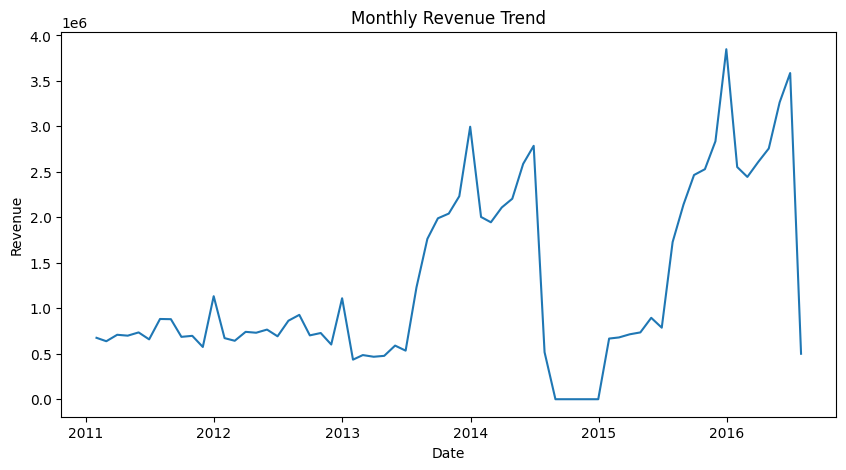

In [52]:
# Since the data is daily transactions, we aggregate monthly revenue:
monthly_sales = df["Revenue"].resample("ME").sum()
plt.figure(figsize=(10,5))
plt.plot(monthly_sales)
plt.title("Monthly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

In [53]:
# We will use last 12 months for testing.
train = monthly_sales[:-12]
test = monthly_sales[-12:]

In [54]:
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                   55
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -778.476
Date:                Wed, 25 Feb 2026   AIC                           1562.952
Time:                        18:42:54   BIC                           1568.919
Sample:                    01-31-2011   HQIC                          1565.253
                         - 07-31-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8401      0.163      5.168      0.000       0.522       1.159
ma.L1         -0.9804      0.129     -7.598      0.000      -1.233      -0.728
sigma2      2.181e+11   5.62e-13   3.88e+23      0.0

In [55]:
# Forecast Next 12 Months
forecast = model_fit.forecast(steps=12)

In [56]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1441439.3818211954
RMSE: 1572386.0337210433


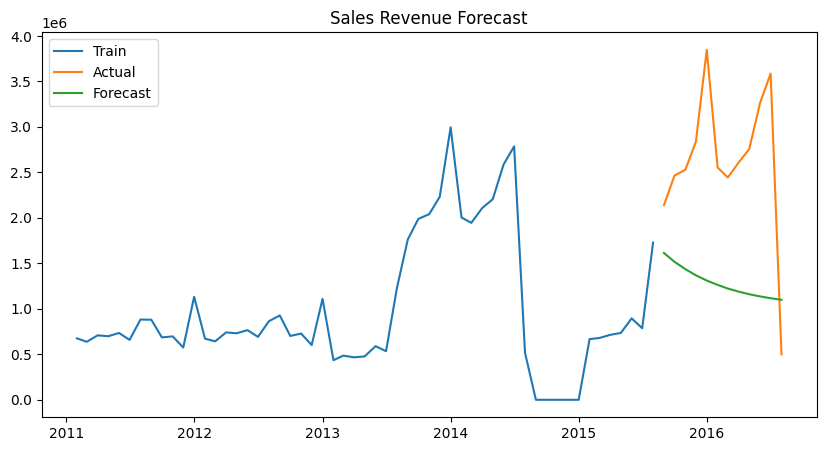

In [57]:
# Plot Forecast vs Actual
plt.figure(figsize=(10,5))
plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")

plt.legend()
plt.title("Sales Revenue Forecast")
plt.show()

In [58]:
version = "v1"
joblib.dump(model_fit, f"arima_sales_model_{version}.pkl")

['arima_sales_model_v1.pkl']